In [5]:
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
ROOT = os.path.join(PROJECT_ROOT, "ETL", "data", "processed")

print("ROOT =", ROOT)
print("Existe ?", os.path.exists(ROOT))


ROOT = c:\Users\HP\Desktop\SAR-Denoising-Project\ETL\data\processed
Existe ? True


In [6]:
import os
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

ROOT = r"C:\Users\HP\Desktop\SAR-Denoising-Project\ETL\data\processed"
L_LIST = ["L1", "L2", "L4", "L8"]

def compute_metrics(folder):
    psnr, ssim = [], []

    for f in os.listdir(folder):
        if f.endswith("_noisy.png"):
            clean_f = f.replace("_noisy.png", "_clean.png")
            noisy_path = os.path.join(folder, f)
            clean_path = os.path.join(folder, clean_f)

            if not os.path.exists(clean_path):
                continue

            noisy = np.array(Image.open(noisy_path).convert("L"), dtype=np.float32)
            clean = np.array(Image.open(clean_path).convert("L"), dtype=np.float32)

            data_range = clean.max() - clean.min()

            psnr.append(
                peak_signal_noise_ratio(clean, noisy, data_range=data_range)
            )
            ssim.append(
                structural_similarity(clean, noisy, data_range=data_range)
            )

    return psnr, ssim


for L in L_LIST:
    L_path = os.path.join(ROOT, L)

    if not os.path.exists(L_path):
        print(f"{L} → dossier absent")
        continue

    psnr_all, ssim_all = compute_metrics(L_path)

    for sub in ["set12", "bsd68"]:
        sub_path = os.path.join(L_path, sub)
        if os.path.exists(sub_path):
            p, s = compute_metrics(sub_path)
            psnr_all += p
            ssim_all += s

    if len(psnr_all) == 0:
        print(f"{L} → aucune image trouvée")
    else:
        print(
            f"{L} → PSNR moyen = {np.mean(psnr_all):.2f} dB | "
            f"SSIM moyen = {np.mean(ssim_all):.4f}"
        )


L1 → PSNR moyen = 14.90 dB | SSIM moyen = 0.2879
L2 → PSNR moyen = 10.58 dB | SSIM moyen = 0.1479
L4 → PSNR moyen = 12.62 dB | SSIM moyen = 0.2111
L8 → PSNR moyen = 14.90 dB | SSIM moyen = 0.2879


In [8]:
best_results = [
    # ---------- MEDIAN FILTER ----------

    {"method": "median", "criterion": "best_ssim", "L": 1, "size": 11, "psnr": 13.9461, "ssim": 0.3691},
    {"method": "median", "criterion": "best_ssim", "L": 2, "size": 11, "psnr": 17.2572, "ssim": 0.4436},
    {"method": "median", "criterion": "best_ssim", "L": 3, "size": 11, "psnr": 18.7119, "ssim": 0.4780},
    {"method": "median", "criterion": "best_ssim", "L": 4, "size": 9,  "psnr": 19.8441, "ssim": 0.5032},
    {"method": "median", "criterion": "best_ssim", "L": 5, "size": 9,  "psnr": 20.4131, "ssim": 0.5250},
    {"method": "median", "criterion": "best_ssim", "L": 7, "size": 7,  "psnr": 21.4578, "ssim": 0.5513},

    # ---------- LEE FILTER ----------
    {"method": "lee", "variant": "vN", "L": 1, "size": 7, "psnr": 16.4458, "ssim": 0.3346},
    {"method": "lee", "variant": "vN", "L": 2, "size": 7, "psnr": 19.0570, "ssim": 0.4092},
    {"method": "lee", "variant": "vN", "L": 3, "size": 7, "psnr": 20.4532, "ssim": 0.4566},
    {"method": "lee", "variant": "vN", "L": 4, "size": 3, "psnr": 21.4071, "ssim": 0.4918},
    {"method": "lee", "variant": "vN", "L": 5, "size": 5, "psnr": 22.1194, "ssim": 0.5210},
    {"method": "lee", "variant": "vN", "L": 7, "size": 5, "psnr": 23.1159, "ssim": 0.5648},

    {"method": "lee", "variant": "classic", "L": 1, "size": 5, "psnr": 13.4049, "ssim": 0.2037},
    {"method": "lee", "variant": "classic", "L": 2, "size": 5, "psnr": 15.4733, "ssim": 0.2740},
    {"method": "lee", "variant": "classic", "L": 3, "size": 5, "psnr": 16.7419, "ssim": 0.3199},
    {"method": "lee", "variant": "classic", "L": 4, "size": 3, "psnr": 17.6686, "ssim": 0.3544},
    {"method": "lee", "variant": "classic", "L": 5, "size": 5, "psnr": 18.4056, "ssim": 0.3829},
    {"method": "lee", "variant": "classic", "L": 7, "size": 5, "psnr": 19.5407, "ssim": 0.4262},
]


In [9]:
best_results.extend([
    {"method": "cnn", "variant": "full_image_inverse_log", "L": 1, "size": None, "psnr": 11.26, "ssim": 0.4850},
    {"method": "cnn", "variant": "full_image_inverse_log", "L": 2, "size": None, "psnr": 10.89, "ssim": 0.3788},
    {"method": "cnn", "variant": "full_image_inverse_log", "L": 4, "size": None, "psnr": 11.00, "ssim": 0.4379},
    {"method": "cnn", "variant": "full_image_inverse_log", "L": 8, "size": None, "psnr": 11.26, "ssim": 0.4849},
])


In [10]:
best_results.extend([
    {"method": "noisy", "variant": "raw", "L": 1, "size": None, "psnr": 14.90, "ssim": 0.2879},
    {"method": "noisy", "variant": "raw", "L": 2, "size": None, "psnr": 10.58, "ssim": 0.1479},
    {"method": "noisy", "variant": "raw", "L": 4, "size": None, "psnr": 12.62, "ssim": 0.2111},
    {"method": "noisy", "variant": "raw", "L": 8, "size": None, "psnr": 14.90, "ssim": 0.2879},
])


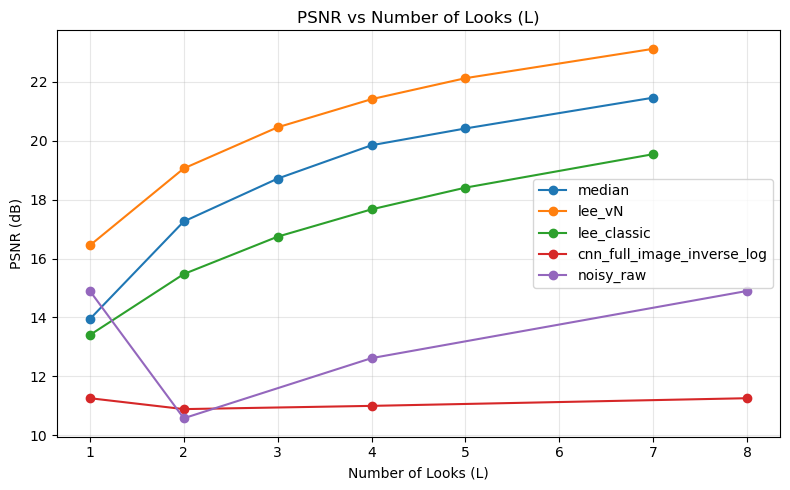

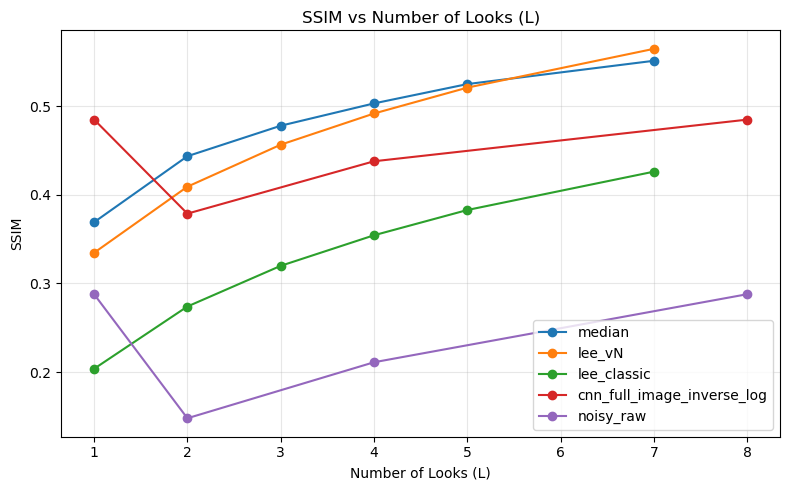

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# DataFrame
# -----------------------------
df = pd.DataFrame(best_results)

# On garde L entre 1 et 8
df = df[df["L"].between(1, 8)]

# Nom unique de modèle
df["model"] = df.apply(
    lambda r: r["method"] if pd.isna(r.get("variant")) else f"{r['method']}_{r['variant']}",
    axis=1
)

# -----------------------------
# 1) PSNR vs L
# -----------------------------
plt.figure(figsize=(8, 5))

for model in df["model"].unique():
    sub = df[df["model"] == model].sort_values("L")
    plt.plot(sub["L"], sub["psnr"], marker="o", label=model)

plt.xlabel("Number of Looks (L)")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs Number of Looks (L)")
plt.xticks(range(1, 9))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 2) SSIM vs L
# -----------------------------
plt.figure(figsize=(8, 5))

for model in df["model"].unique():
    sub = df[df["model"] == model].sort_values("L")
    plt.plot(sub["L"], sub["ssim"], marker="o", label=model)

plt.xlabel("Number of Looks (L)")
plt.ylabel("SSIM")
plt.title("SSIM vs Number of Looks (L)")
plt.xticks(range(1, 9))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
